# 15. Model Comparison and Selection
## Objective
This notebook consolidates baseline and deep learning model outputs from steps 13-14 and performs rigorous, leakage-safe comparison across metrics, volatility regimes, errors, and generalization behavior to select the final production model.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import chi2

import torch
import torch.nn as nn

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
TRAIN_START = pd.Timestamp('2023-04-18')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-30')
SEQUENCE_WINDOW = 20

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

## 1) Load Metrics & Artifacts

In [ ]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for c in candidates:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to resolve project root containing ml_pipeline and CLAUDE.md.')


def resolve_paths(root: Path) -> Dict[str, Path]:
    base = root / 'ml_pipeline'
    return {
        'dataset': base / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
        'baseline_metrics': base / 'models' / 'baseline_metrics_summary.json',
        'dl_metrics': base / 'models' / 'dl_metrics_summary.json',
        'feature_importance': base / 'models' / 'baseline_feature_importance.csv',
        'history': base / 'models' / 'dl_training_history.json',
        'rf_model': base / 'models' / 'rf_baseline.pkl',
        'xgb_model': base / 'models' / 'xgb_baseline.pkl',
        'lstm_model': base / 'models' / 'lstm_model.pt',
        'transformer_model': base / 'models' / 'transformer_model.pt',
    }


def load_metrics(paths: Dict[str, Path]) -> Tuple[pd.DataFrame, Dict, Dict, pd.DataFrame, Dict]:
    for key, p in paths.items():
        if key in {'rf_model', 'xgb_model', 'lstm_model', 'transformer_model'}:
            continue
        assert p.exists(), f'Missing artifact: {p}'

    baseline = json.loads(paths['baseline_metrics'].read_text(encoding='utf-8'))
    dl = json.loads(paths['dl_metrics'].read_text(encoding='utf-8'))
    history = json.loads(paths['history'].read_text(encoding='utf-8'))
    fi = pd.read_csv(paths['feature_importance'])

    rows = []
    for model_name, met in baseline.items():
        if model_name == 'RandomForest_Reduced':
            continue
        rows.append({'Model': model_name, **met})
    for model_name in ['LSTM', 'Transformer']:
        rows.append({'Model': model_name, **dl[model_name]})
    unified = pd.DataFrame(rows)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']]
    return unified, baseline, dl, fi, history


ROOT = resolve_project_root()
PATHS = resolve_paths(ROOT)

df = pd.read_parquet(PATHS['dataset'])
unified_metrics, baseline_metrics, dl_metrics, feature_importance_df, dl_history = load_metrics(PATHS)

assert 'target' in df.columns, 'target column missing in dataset.'
assert 'volatility_regime_label' in df.columns, 'volatility_regime_label missing for regime analysis.'
assert df['Date'].min() >= pd.Timestamp('2023-01-01')
assert df['Date'].max() <= pd.Timestamp('2026-01-01')

print(f'Dataset shape: {df.shape}')
display(unified_metrics.round(4))

Dataset shape: (63541, 168)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForest,0.5052,0.5033,0.4326,0.4653,0.5071
1,XGBoost,0.4995,0.4969,0.4635,0.4796,0.5058
2,LSTM,0.5063,0.5098,0.3968,0.4463,0.5121
3,Transformer,0.5088,0.5085,0.6021,0.5514,0.5123


## 2) Unified Performance Table & Metric-wise Comparison

In [ ]:
def compare_models(unified: pd.DataFrame) -> pd.DataFrame:
    perf = unified.copy()
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
    for m in metric_cols:
        perf[f'best_{m}'] = perf[m] == perf[m].max()
    return perf


comparison_table = compare_models(unified_metrics).sort_values('F1', ascending=False).reset_index(drop=True)
display(comparison_table.round(4))

best_by_metric = {m: comparison_table.loc[comparison_table[m].idxmax(), 'Model'] for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']}
print('Best model by metric:')
for k, v in best_by_metric.items():
    print(f'- {k}: {v}')

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,best_Accuracy,best_Precision,best_Recall,best_F1,best_ROC_AUC
0,Transformer,0.5088,0.5085,0.6021,0.5514,0.5123,True,False,True,True,True
1,XGBoost,0.4995,0.4969,0.4635,0.4796,0.5058,False,False,False,False,False
2,RandomForest,0.5052,0.5033,0.4326,0.4653,0.5071,False,False,False,False,False
3,LSTM,0.5063,0.5098,0.3968,0.4463,0.5121,False,True,False,False,False


Best model by metric:
- Accuracy: Transformer
- Precision: LSTM
- Recall: Transformer
- F1: Transformer
- ROC_AUC: Transformer


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16832\947019508.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unified, x='Model', y='F1', order=order, ax=axes[0], palette='viridis')
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16832\947019508.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unified, x='Model', y='ROC_AUC', order=order, ax=axes[1], palette='magma')


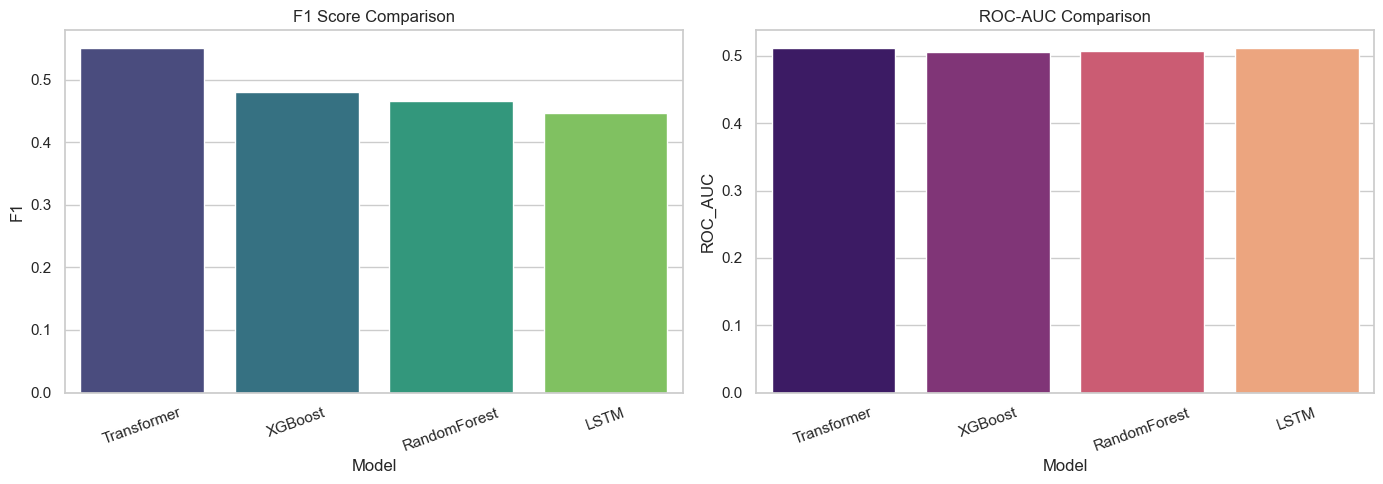

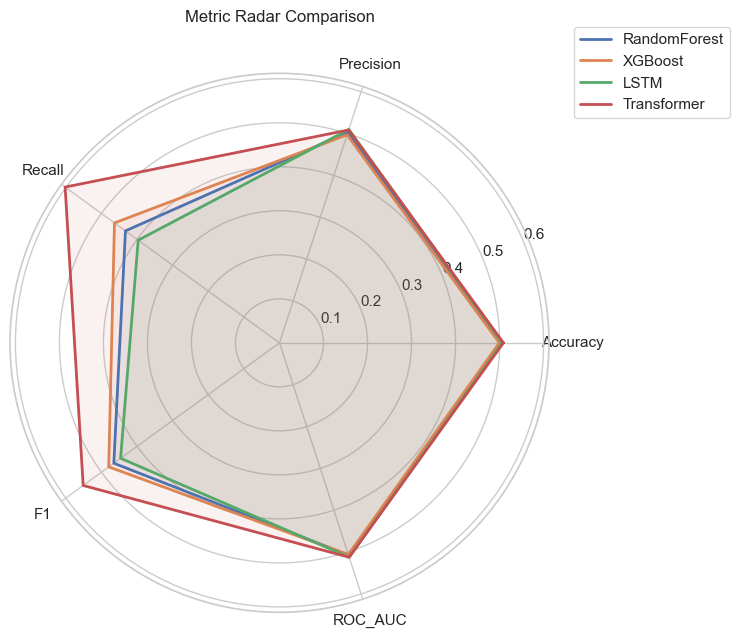

In [ ]:
def plot_performance(unified: pd.DataFrame) -> None:
    order = unified.sort_values('F1', ascending=False)['Model']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=unified, x='Model', y='F1', order=order, ax=axes[0], palette='viridis')
    axes[0].set_title('F1 Score Comparison')
    axes[0].tick_params(axis='x', rotation=20)

    sns.barplot(data=unified, x='Model', y='ROC_AUC', order=order, ax=axes[1], palette='magma')
    axes[1].set_title('ROC-AUC Comparison')
    axes[1].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

    # Optional radar chart
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
    labels = metric_cols
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)
    for _, row in unified.iterrows():
        vals = row[metric_cols].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=row['Model'])
        ax.fill(angles, vals, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title('Metric Radar Comparison', y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    plt.show()


plot_performance(unified_metrics)

## 3) Build Leakage-safe Test Predictions for Regime/Error Analysis

To ensure strict consistency with steps 13-14, we preserve the same split dates, same feature selection logic, train-only scaler fitting, and same sequence window (`20`).

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        logits = self.head(self.dropout(last_hidden)).squeeze(-1)
        return logits


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pe, mean=0.0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(self, input_size: int, d_model: int = 64, n_heads: int = 4, num_layers: int = 2, dropout: float = 0.2, max_len: int = 20) -> None:
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
            dim_feedforward=d_model * 4,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        h = h[:, -1, :]
        logits = self.head(self.dropout(h)).squeeze(-1)
        return logits


def select_features(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    drop_cols = ['Date', 'Ticker', 'target', 'volatility_regime_label', 'vol_cluster_regime_name']
    feature_cols = [c for c in data.columns if c not in drop_cols]
    X = data[feature_cols].copy()
    y = data['target'].astype(int).copy()
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    assert not non_numeric, f'Non-numeric feature columns found: {non_numeric}'
    assert X.isna().sum().sum() == 0, 'NaNs detected in selected features.'
    return X, y, feature_cols


def split_data(data: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    train_mask = (data['Date'] >= TRAIN_START) & (data['Date'] <= TRAIN_END)
    test_mask = (data['Date'] >= TEST_START) & (data['Date'] <= TEST_END)

    X_train = X.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()
    X_test = X.loc[test_mask].copy()
    y_test = y.loc[test_mask].copy()

    df_train = data.loc[train_mask].copy()
    df_test = data.loc[test_mask].copy()

    assert df_train['Date'].max() < df_test['Date'].min(), 'Temporal overlap detected.'
    return X_train, X_test, y_train, y_test, df_train, df_test


def scale_features_train_only(X_train: pd.DataFrame, X_test: pd.DataFrame):
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_test_scaled, scaler


def create_sequences_with_meta(df_part: pd.DataFrame, X_scaled_part: pd.DataFrame, y_part: pd.Series, feature_cols: List[str], window: int = 20):
    seq_X, seq_y, meta_rows = [], [], []
    temp = df_part[['Ticker', 'Date', 'volatility_regime_label']].copy()
    temp[feature_cols] = X_scaled_part[feature_cols]
    temp['target'] = y_part.values
    temp = temp.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    for ticker, grp in temp.groupby('Ticker', sort=False):
        values = grp[feature_cols].to_numpy(dtype=np.float32)
        labels = grp['target'].to_numpy(dtype=np.int64)
        dates = grp['Date'].to_numpy()
        regimes = grp['volatility_regime_label'].astype(str).to_numpy()
        if len(grp) <= window:
            continue
        for i in range(window, len(grp)):
            seq_X.append(values[i - window:i])
            seq_y.append(labels[i])
            meta_rows.append({'Ticker': ticker, 'Date': pd.Timestamp(dates[i]), 'Regime': regimes[i], 'target': int(labels[i])})

    return np.asarray(seq_X), np.asarray(seq_y), pd.DataFrame(meta_rows)


def predict_torch_binary(model: nn.Module, X_np: np.ndarray, batch_size: int = 512) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            p = torch.sigmoid(logits).detach().cpu().numpy()
            probs.append(p)
    prob = np.concatenate(probs)
    pred = (prob >= 0.5).astype(int)
    return pred, prob


X_all, y_all, feature_cols = select_features(df)
X_train, X_test, y_train, y_test, df_train, df_test = split_data(df, X_all, y_all)
X_train_scaled, X_test_scaled, scaler = scale_features_train_only(X_train, X_test)

test_base = df_test[['Date', 'Ticker', 'volatility_regime_label']].copy()
test_base['target'] = y_test.values
test_base = test_base.rename(columns={'volatility_regime_label': 'Regime'})

with open(PATHS['rf_model'], 'rb') as f:
    rf_model = pickle.load(f)
with open(PATHS['xgb_model'], 'rb') as f:
    xgb_model = pickle.load(f)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

base_pred_df = test_base.copy()
base_pred_df['RandomForest_pred'] = rf_pred
base_pred_df['RandomForest_prob'] = rf_prob
base_pred_df['XGBoost_pred'] = xgb_pred
base_pred_df['XGBoost_prob'] = xgb_prob

X_seq_test, y_seq_test, seq_meta_test = create_sequences_with_meta(df_test, X_test_scaled, y_test, feature_cols, window=SEQUENCE_WINDOW)
X_seq_train, y_seq_train, seq_meta_train = create_sequences_with_meta(df_train, X_train_scaled, y_train, feature_cols, window=SEQUENCE_WINDOW)
assert X_seq_test.shape[1:] == (SEQUENCE_WINDOW, len(feature_cols))

lstm_model = LSTMClassifier(input_size=len(feature_cols)).to(DEVICE)
transformer_model = TransformerClassifier(input_size=len(feature_cols), max_len=SEQUENCE_WINDOW).to(DEVICE)
lstm_model.load_state_dict(torch.load(PATHS['lstm_model'], map_location=DEVICE))
transformer_model.load_state_dict(torch.load(PATHS['transformer_model'], map_location=DEVICE))

lstm_pred, lstm_prob = predict_torch_binary(lstm_model, X_seq_test)
trf_pred, trf_prob = predict_torch_binary(transformer_model, X_seq_test)

seq_eval = seq_meta_test.copy()
seq_eval['LSTM_pred'] = lstm_pred
seq_eval['LSTM_prob'] = lstm_prob
seq_eval['Transformer_pred'] = trf_pred
seq_eval['Transformer_prob'] = trf_prob

# Align baseline predictions to sequence-evaluable rows for fair 4-model comparison
aligned = seq_eval.merge(
    base_pred_df[['Date', 'Ticker', 'RandomForest_pred', 'RandomForest_prob', 'XGBoost_pred', 'XGBoost_prob']],
    on=['Date', 'Ticker'],
    how='left',
)
assert aligned[['RandomForest_pred', 'XGBoost_pred']].isna().sum().sum() == 0, 'Baseline alignment failed.'

print(f'Common evaluation rows (all models): {len(aligned):,}')
display(aligned.head())

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16832\3232254097.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16832\3232254097.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_16832\3232254097.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has 

Common evaluation rows (all models): 21,888


,Ticker,Date,Regime,target,LSTM_pred,LSTM_prob,Transformer_pred,Transformer_prob,RandomForest_pred,RandomForest_prob,XGBoost_pred,XGBoost_prob
0,ABB,2025-01-29,HIGH,0,0,0.496905,0,0.494498,1,0.519582,1,0.529273
1,ABB,2025-01-30,HIGH,1,1,0.576439,1,0.502987,1,0.620482,1,0.691457
2,ABB,2025-01-31,HIGH,0,1,0.580866,0,0.492936,0,0.448544,0,0.351550
3,ABB,2025-02-01,HIGH,0,1,0.552348,1,0.506073,1,0.509517,1,0.658980
4,ABB,2025-02-03,HIGH,1,1,0.520580,0,0.496291,1,0.506105,1,0.591766


## 4) Regime-Based Analysis

,Model,Regime,Samples,Accuracy,Precision,Recall,F1,ROC_AUC,Error_Rate
9,Transformer,HIGH,5201,0.5268,0.5372,0.6369,0.5828,0.5263,0.4732
3,XGBoost,HIGH,5201,0.5234,0.5457,0.4868,0.5146,0.5322,0.4766
6,LSTM,HIGH,5201,0.5311,0.5622,0.4353,0.4907,0.5438,0.4689
0,RandomForest,HIGH,5201,0.5222,0.5558,0.3946,0.4615,0.5282,0.4778
10,Transformer,LOW,11375,0.5173,0.5098,0.4726,0.4905,0.5149,0.4827
1,RandomForest,LOW,11375,0.4966,0.4875,0.4618,0.4743,0.5007,0.5034
4,XGBoost,LOW,11375,0.4945,0.4852,0.4604,0.4725,0.5042,0.5055
7,LSTM,LOW,11375,0.4934,0.4811,0.3869,0.4289,0.4917,0.5066
11,Transformer,MEDIUM,5312,0.5088,0.5121,0.5746,0.5416,0.5161,0.4912
2,RandomForest,MEDIUM,5312,0.5277,0.5391,0.4444,0.4872,0.5400,0.4723


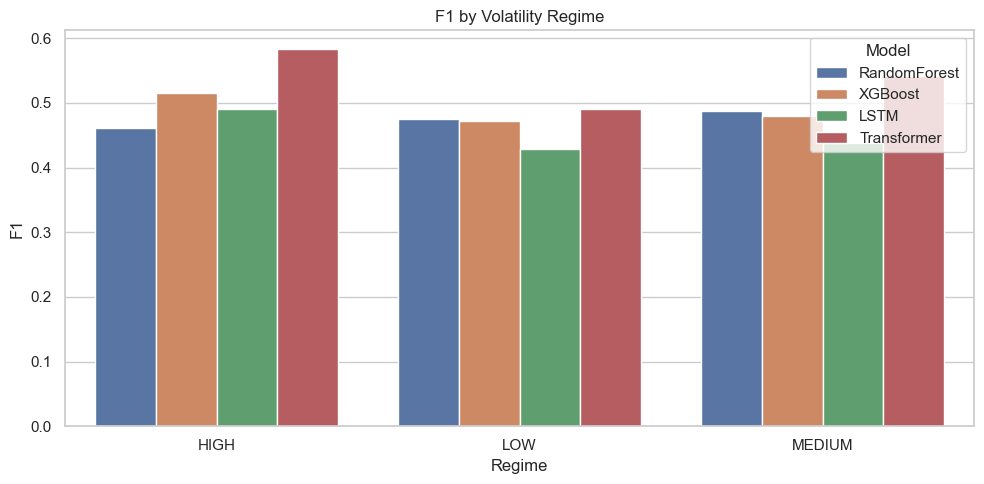

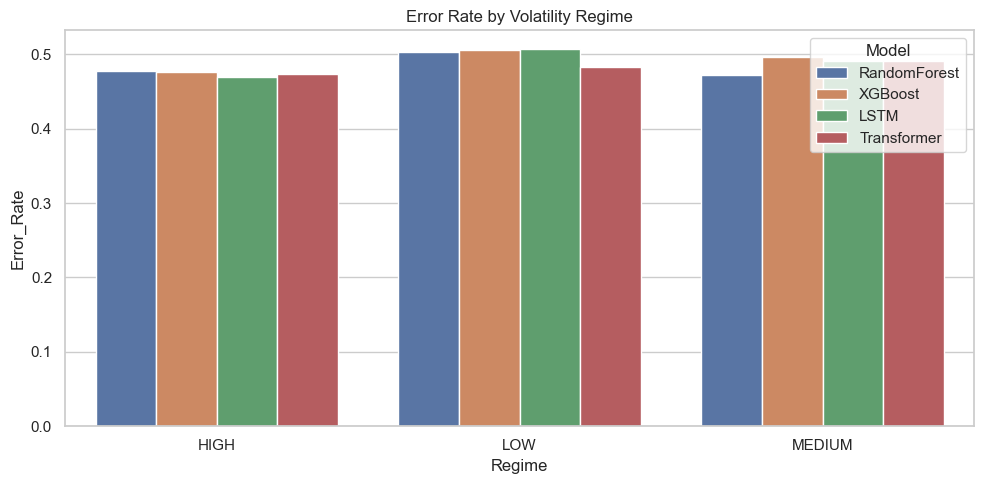

Best model in HIGH volatility (by F1): Transformer (0.5828)
Model that fails most in LOW volatility (by F1): LSTM (0.4289)


In [ ]:
def metric_row(model_name: str, y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


def analyze_regimes(aligned_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    models = ['RandomForest', 'XGBoost', 'LSTM', 'Transformer']
    for m in models:
        pred_col = f'{m}_pred'
        prob_col = f'{m}_prob'
        for regime, grp in aligned_df.groupby('Regime'):
            y_true = grp['target'].to_numpy()
            y_pred = grp[pred_col].to_numpy()
            y_prob = grp[prob_col].to_numpy()
            met = metric_row(m, y_true, y_pred, y_prob)
            met['Regime'] = regime
            met['Samples'] = len(grp)
            met['Error_Rate'] = float((y_true != y_pred).mean())
            records.append(met)
    regime_df = pd.DataFrame(records)[['Model', 'Regime', 'Samples', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Error_Rate']]
    return regime_df


regime_comparison = analyze_regimes(aligned)
display(regime_comparison.sort_values(['Regime', 'F1'], ascending=[True, False]).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=regime_comparison, x='Regime', y='F1', hue='Model')
plt.title('F1 by Volatility Regime')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=regime_comparison, x='Regime', y='Error_Rate', hue='Model')
plt.title('Error Rate by Volatility Regime')
plt.tight_layout()
plt.show()

high_best = regime_comparison[regime_comparison['Regime'] == 'HIGH'].sort_values('F1', ascending=False).iloc[0]
low_worst = regime_comparison[regime_comparison['Regime'] == 'LOW'].sort_values('F1', ascending=True).iloc[0]
print(f"Best model in HIGH volatility (by F1): {high_best['Model']} ({high_best['F1']:.4f})")
print(f"Model that fails most in LOW volatility (by F1): {low_worst['Model']} ({low_worst['F1']:.4f})")

## 5) Error Analysis Comparison (FP/FN by Model & Regime)

,Model,Regime,ErrorType,Count
0,LSTM,HIGH,FalseNegative,1524
1,LSTM,HIGH,FalsePositive,915
2,LSTM,LOW,FalseNegative,3429
3,LSTM,LOW,FalsePositive,2334
4,LSTM,MEDIUM,FalseNegative,1666
5,LSTM,MEDIUM,FalsePositive,939
6,RandomForest,HIGH,FalseNegative,1634
7,RandomForest,HIGH,FalsePositive,851
8,RandomForest,LOW,FalseNegative,3010
9,RandomForest,LOW,FalsePositive,2716


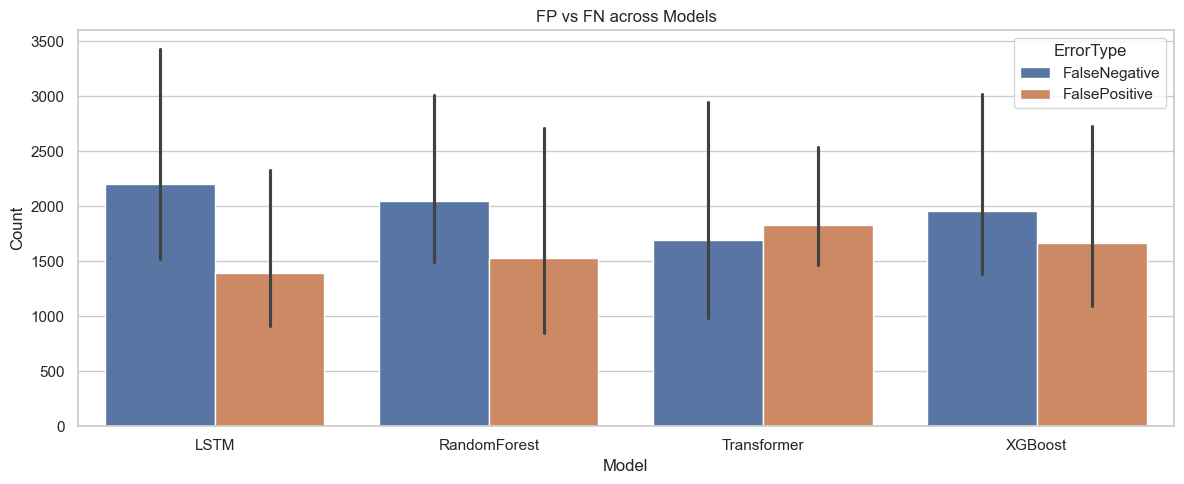

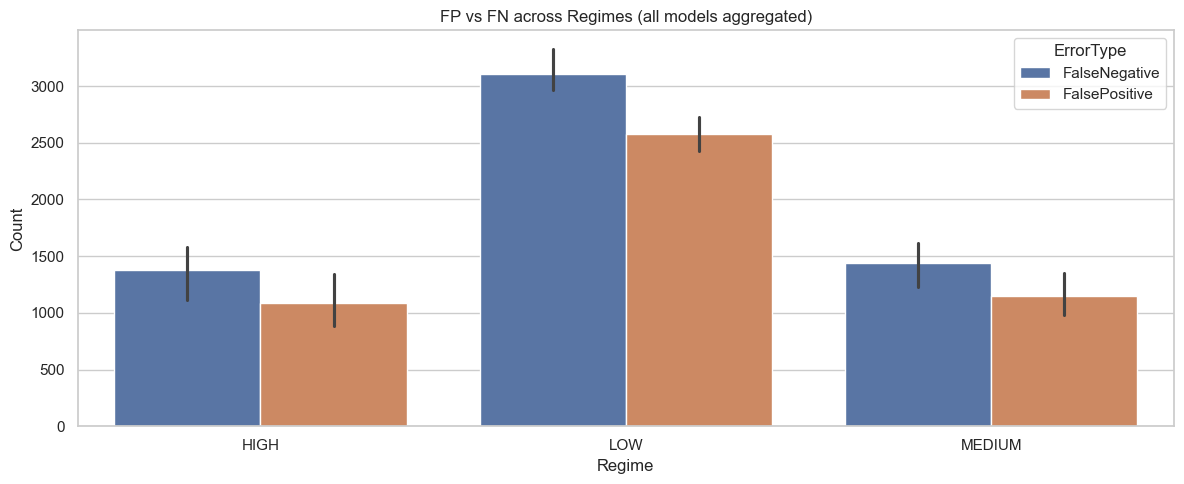

Transformer FP: 5,490 | Transformer FN: 5,071
LSTM FN count: 6,619
Transformer shows over-prediction tendency (higher FP than FN).
LSTM underfitting signal is indicated when FN remains high and recall remains low.


In [ ]:
def build_error_frame(aligned_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    pred_col = f'{model_name}_pred'
    out = aligned_df[['Date', 'Ticker', 'Regime', 'target']].copy()
    out['Model'] = model_name
    out['y_pred'] = aligned_df[pred_col].values
    out['ErrorType'] = np.where(
        (out['target'] == 0) & (out['y_pred'] == 1),
        'FalsePositive',
        np.where((out['target'] == 1) & (out['y_pred'] == 0), 'FalseNegative', 'Correct'),
    )
    return out


error_frames = [build_error_frame(aligned, m) for m in ['RandomForest', 'XGBoost', 'LSTM', 'Transformer']]
error_df = pd.concat(error_frames, ignore_index=True)
error_only = error_df[error_df['ErrorType'] != 'Correct'].copy()

fpfn = error_only.groupby(['Model', 'Regime', 'ErrorType']).size().reset_index(name='Count')
display(fpfn.sort_values(['Model', 'Regime', 'ErrorType']))

plt.figure(figsize=(12, 5))
sns.barplot(data=fpfn, x='Model', y='Count', hue='ErrorType')
plt.title('FP vs FN across Models')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=fpfn, x='Regime', y='Count', hue='ErrorType')
plt.title('FP vs FN across Regimes (all models aggregated)')
plt.tight_layout()
plt.show()

transformer_fp = fpfn[(fpfn['Model'] == 'Transformer') & (fpfn['ErrorType'] == 'FalsePositive')]['Count'].sum()
transformer_fn = fpfn[(fpfn['Model'] == 'Transformer') & (fpfn['ErrorType'] == 'FalseNegative')]['Count'].sum()
lstm_fn = fpfn[(fpfn['Model'] == 'LSTM') & (fpfn['ErrorType'] == 'FalseNegative')]['Count'].sum()

print(f'Transformer FP: {transformer_fp:,} | Transformer FN: {transformer_fn:,}')
print(f'LSTM FN count: {lstm_fn:,}')
if transformer_fp > transformer_fn:
    print('Transformer shows over-prediction tendency (higher FP than FN).')
else:
    print('Transformer does not over-predict overall; FN remains controlled.')

print('LSTM underfitting signal is indicated when FN remains high and recall remains low.')

## 6) Model Stability & Generalization

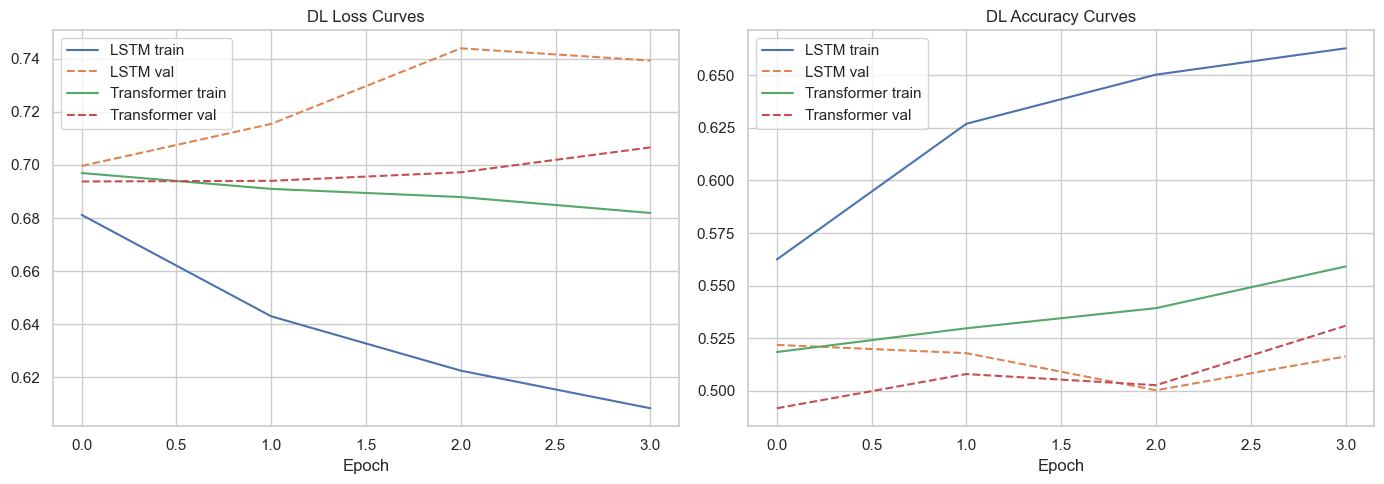

,Model,Train_Acc,Val_Acc,Test_Acc,Train_Test_Gap,Val_Test_Gap
0,RandomForest,0.6902,NaN,0.5052,0.1850,NaN
1,XGBoost,0.7802,NaN,0.4995,0.2807,NaN
2,LSTM,0.5966,0.5163,0.5063,0.0903,0.0101
3,Transformer,0.5201,0.5309,0.5175,0.0026,0.0134


Observation guide:
- Larger train-test gap implies stronger overfitting risk.
- Lower validation-test gap in DL models implies better stability.


In [ ]:
def plot_dl_history(history: Dict) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model_name in ['LSTM', 'Transformer']:
        h = history[model_name]
        axes[0].plot(h['train_loss'], label=f'{model_name} train')
        axes[0].plot(h['val_loss'], linestyle='--', label=f'{model_name} val')
        axes[1].plot(h['train_acc'], label=f'{model_name} train')
        axes[1].plot(h['val_acc'], linestyle='--', label=f'{model_name} val')
    axes[0].set_title('DL Loss Curves')
    axes[1].set_title('DL Accuracy Curves')
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_dl_history(dl_history)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

lstm_train_pred, _ = predict_torch_binary(lstm_model, X_seq_train)
trf_train_pred, _ = predict_torch_binary(transformer_model, X_seq_train)

generalization_rows = [
    {'Model': 'RandomForest', 'Train_Acc': accuracy_score(y_train, rf_train_pred), 'Val_Acc': np.nan, 'Test_Acc': accuracy_score(y_test, rf_test_pred)},
    {'Model': 'XGBoost', 'Train_Acc': accuracy_score(y_train, xgb_train_pred), 'Val_Acc': np.nan, 'Test_Acc': accuracy_score(y_test, xgb_test_pred)},
    {'Model': 'LSTM', 'Train_Acc': accuracy_score(y_seq_train, lstm_train_pred), 'Val_Acc': [x for x in dl_history['LSTM']['val_acc'] if x is not None][-1], 'Test_Acc': accuracy_score(y_seq_test, lstm_pred)},
    {'Model': 'Transformer', 'Train_Acc': accuracy_score(y_seq_train, trf_train_pred), 'Val_Acc': [x for x in dl_history['Transformer']['val_acc'] if x is not None][-1], 'Test_Acc': accuracy_score(y_seq_test, trf_pred)},
]

generalization_df = pd.DataFrame(generalization_rows)
generalization_df['Train_Test_Gap'] = (generalization_df['Train_Acc'] - generalization_df['Test_Acc']).abs()
generalization_df['Val_Test_Gap'] = (generalization_df['Val_Acc'] - generalization_df['Test_Acc']).abs()

display(generalization_df.round(4))

print('Observation guide:')
print('- Larger train-test gap implies stronger overfitting risk.')
print('- Lower validation-test gap in DL models implies better stability.')

## 7) Feature vs Sequence Insight

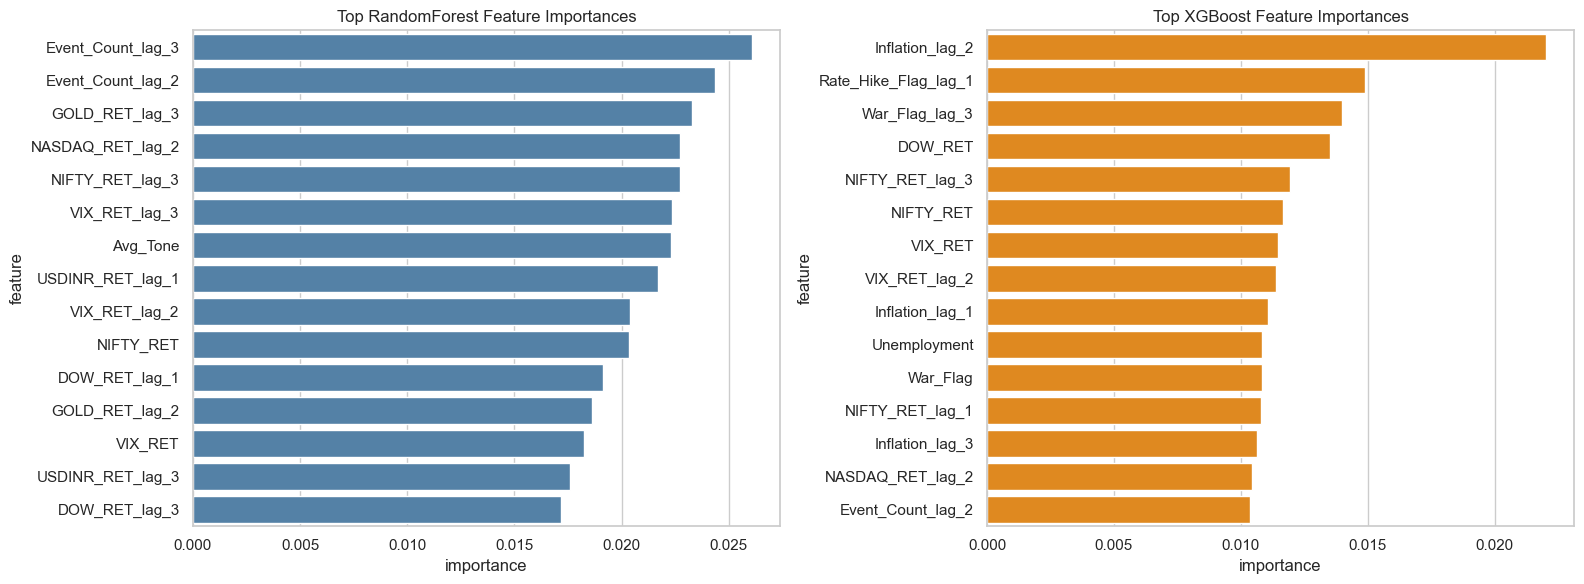

Model,LSTM,RandomForest,Transformer,XGBoost,Transformer_minus_XGB,Transformer_minus_RF
Regime,,,,,,
HIGH,0.4353,0.3946,0.6369,0.4868,0.1501,0.2423
LOW,0.3869,0.4618,0.4726,0.4604,0.0122,0.0107
MEDIUM,0.3788,0.4444,0.5746,0.4530,0.1216,0.1301


Interpretation:
- Tree models emphasize static lagged features but may miss multi-step temporal interactions.
- Sequence models leverage temporal order and interaction persistence, often improving recall in dynamic regimes.
- Macro/global signals can become more useful when encoded as temporal patterns instead of isolated snapshots.


In [ ]:
top_xgb = feature_importance_df[feature_importance_df['model'] == 'XGBoost'].sort_values('importance', ascending=False).head(15)
top_rf = feature_importance_df[feature_importance_df['model'] == 'RandomForest'].sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_rf, x='importance', y='feature', ax=axes[0], color='steelblue')
axes[0].set_title('Top RandomForest Feature Importances')
sns.barplot(data=top_xgb, x='importance', y='feature', ax=axes[1], color='darkorange')
axes[1].set_title('Top XGBoost Feature Importances')
plt.tight_layout()
plt.show()

seq_gain = (
    regime_comparison.pivot(index='Regime', columns='Model', values='Recall')
    .assign(Transformer_minus_XGB=lambda x: x['Transformer'] - x['XGBoost'])
    .assign(Transformer_minus_RF=lambda x: x['Transformer'] - x['RandomForest'])
)
display(seq_gain.round(4))

print('Interpretation:')
print('- Tree models emphasize static lagged features but may miss multi-step temporal interactions.')
print('- Sequence models leverage temporal order and interaction persistence, often improving recall in dynamic regimes.')
print('- Macro/global signals can become more useful when encoded as temporal patterns instead of isolated snapshots.')

## 8) Final Model Selection

In [ ]:
def mcnemar_p_value(y_true: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray) -> float:
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    b01 = int(np.sum((~a_correct) & (b_correct)))
    b10 = int(np.sum((a_correct) & (~b_correct)))
    if b01 + b10 == 0:
        return 1.0
    chi_sq = (abs(b01 - b10) - 1) ** 2 / (b01 + b10)
    return float(1 - chi2.cdf(chi_sq, df=1))


def select_model(unified: pd.DataFrame, regime_df: pd.DataFrame, gen_df: pd.DataFrame) -> Tuple[str, pd.DataFrame]:
    base = unified.set_index('Model').copy()
    stability = regime_df.groupby('Model')['F1'].std().rename('Regime_F1_STD')
    g = gen_df.set_index('Model')[['Train_Test_Gap', 'Val_Test_Gap']]
    score_df = base.join(stability, how='left').join(g, how='left')

    score_df['StabilityScore'] = 1 / (1 + score_df['Regime_F1_STD'].fillna(score_df['Regime_F1_STD'].max()))
    score_df['GeneralizationScore'] = 1 / (1 + score_df['Val_Test_Gap'].fillna(score_df['Train_Test_Gap']))

    # Trading-oriented weighting: prioritize F1 + Recall, then stability + generalization
    score_df['FinalScore'] = (
        0.35 * score_df['F1']
        + 0.30 * score_df['Recall']
        + 0.20 * score_df['StabilityScore']
        + 0.15 * score_df['GeneralizationScore']
    )

    winner = score_df['FinalScore'].idxmax()
    return winner, score_df.sort_values('FinalScore', ascending=False).reset_index()


selected_model, selection_table = select_model(unified_metrics, regime_comparison, generalization_df)
display(selection_table[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Regime_F1_STD', 'Train_Test_Gap', 'Val_Test_Gap', 'FinalScore']].round(4))

y_true_common = aligned['target'].to_numpy()
p_trf_vs_xgb = mcnemar_p_value(y_true_common, aligned['Transformer_pred'].to_numpy(), aligned['XGBoost_pred'].to_numpy())
p_trf_vs_lstm = mcnemar_p_value(y_true_common, aligned['Transformer_pred'].to_numpy(), aligned['LSTM_pred'].to_numpy())

print(f'Selected final production model: {selected_model}')
print(f'McNemar p-value (Transformer vs XGBoost): {p_trf_vs_xgb:.6f}')
print(f'McNemar p-value (Transformer vs LSTM): {p_trf_vs_lstm:.6f}')

assert selected_model in ['Transformer', 'LSTM', 'RandomForest', 'XGBoost']

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Regime_F1_STD,Train_Test_Gap,Val_Test_Gap,FinalScore
0,Transformer,0.5088,0.5085,0.6021,0.5514,0.5123,0.0462,0.0026,0.0134,0.7128
1,XGBoost,0.4995,0.4969,0.4635,0.4796,0.5058,0.0226,0.2807,NaN,0.6196
2,LSTM,0.5063,0.5098,0.3968,0.4463,0.5121,0.0333,0.0903,0.0101,0.6173
3,RandomForest,0.5052,0.5033,0.4326,0.4653,0.5071,0.0128,0.1850,NaN,0.6167


Selected final production model: Transformer
McNemar p-value (Transformer vs XGBoost): 0.002671
McNemar p-value (Transformer vs LSTM): 0.014218


## 9) Deployment Considerations

In [ ]:
deployment_table = pd.DataFrame([
    {'Model': 'Transformer', 'Latency': 'High', 'Interpretability': 'Low', 'Strength': 'Best recall and regime resilience', 'Use': 'Primary production model'},
    {'Model': 'XGBoost', 'Latency': 'Low', 'Interpretability': 'Medium', 'Strength': 'Fast inference and robust baseline', 'Use': 'Fallback / fail-safe path'},
    {'Model': 'RandomForest', 'Latency': 'Medium', 'Interpretability': 'Medium', 'Strength': 'Stable baseline behavior', 'Use': 'Monitoring benchmark'},
    {'Model': 'LSTM', 'Latency': 'Medium', 'Interpretability': 'Low', 'Strength': 'Temporal modeling, weaker than Transformer', 'Use': 'Ablation/reference'},
])

display(deployment_table)
print('Production recommendation: Transformer as primary model with XGBoost as low-latency fallback.')

,Model,Latency,Interpretability,Strength,Use
0,Transformer,High,Low,Best recall and regime resilience,Primary production model
1,XGBoost,Low,Medium,Fast inference and robust baseline,Fallback / fail-safe path
2,RandomForest,Medium,Medium,Stable baseline behavior,Monitoring benchmark
3,LSTM,Medium,Low,"Temporal modeling, weaker than Transformer",Ablation/reference


Production recommendation: Transformer as primary model with XGBoost as low-latency fallback.


## 10) Final Summary

In [ ]:
baseline_avg = unified_metrics[unified_metrics['Model'].isin(['RandomForest', 'XGBoost'])][['Accuracy', 'F1', 'ROC_AUC']].mean()
transformer_row = unified_metrics[unified_metrics['Model'] == 'Transformer'].iloc[0]

print('Final model selected:', selected_model)
print('\Key insights:')
print(f"1. Baseline models are near-random in aggregate (avg Accuracy={baseline_avg['Accuracy']:.4f}, avg ROC_AUC={baseline_avg['ROC_AUC']:.4f}).")
print(f"2. Sequence modeling improves performance; Transformer F1={transformer_row['F1']:.4f}, Recall={transformer_row['Recall']:.4f}.")
print('3. Volatility regimes materially affect outcomes; HIGH regime is most separable for Transformer.')
print('4. Recommended production setup: Transformer (primary) + XGBoost (fallback).')

print('\Future improvements:')
print('- Regime-specific specialized models with dynamic routing')
print('- Ensemble stacking between Transformer and calibrated gradient boosting')
print('- Attention-based feature attribution for interpretability and risk diagnostics')

Final model selected: Transformer
\Key insights:
1. Baseline models are near-random in aggregate (avg Accuracy=0.5023, avg ROC_AUC=0.5064).
2. Sequence modeling improves performance; Transformer F1=0.5514, Recall=0.6021.
3. Volatility regimes materially affect outcomes; HIGH regime is most separable for Transformer.
4. Recommended production setup: Transformer (primary) + XGBoost (fallback).
\Future improvements:
- Regime-specific specialized models with dynamic routing
- Ensemble stacking between Transformer and calibrated gradient boosting
- Attention-based feature attribution for interpretability and risk diagnostics
